# MobileNet 학습 노트북

이 폴더는 `resnet` / `resnet_dataset` 흐름과 같은 방식으로 MobileNet 계열 모델을 학습하기 위한 노트북을 담고 있습니다.

## 폴더 구조

```text
mobilenet/
  mobilenet.ipynb
  README.md
  checkpoints/

mobilenet_dataset/
  train/
    Attentive/
    Drowsy/
    LookingAway/
  val/
    Attentive/
    Drowsy/
    LookingAway/
  test/
    Attentive/
    Drowsy/
    LookingAway/
```

## 실행 방법

1. Jupyter에서 `mobilenet/mobilenet.ipynb`를 엽니다.
2. 위에서 아래로 셀을 순서대로 실행합니다.
3. 기본 모델은 `mobilenet_v3_small`입니다.
4. 모델을 바꾸려면 설정 셀의 `BACKBONE` 값을 변경합니다.

## 지원 모델

- `mobilenet_v2`
- `mobilenet_v3_small`
- `mobilenet_v3_large`

## 데이터 준비 규칙

- 원본 데이터는 `dataset/Attentive`, `dataset/Drowsy`, `dataset/LookingAway` 구조를 사용합니다.
- 노트북 실행 시 `mobilenet_dataset/train`, `mobilenet_dataset/val`, `mobilenet_dataset/test`로 자동 분할됩니다.
- 학습된 최고 성능 모델은 `mobilenet/checkpoints` 아래에 저장됩니다.


In [49]:
# 1) MobileNet 학습 노트북
# 3. 기본 모델은 `mobilenet_v3_small`입니다.
from pathlib import Path
from collections import Counter, deque
import random
import shutil

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9

CLASS_NAMES = ['Attentive', 'Drowsy', 'LookingAway']
IMAGE_EXTENSIONS = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']

IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0
BACKBONE = 'mobilenet_v3_large'  # 'mobilenet_v3_small' or 'mobilenet_v3_large'
USE_PRETRAINED = True
FREEZE_BACKBONE = False
FINE_TUNE_LAST_BLOCK = True
DROPOUT = 0.2
EPOCHS = 40
LR_HEAD = 1e-3
LR_BACKBONE = 1e-4
WEIGHT_DECAY = 1e-4
USE_CLASS_WEIGHTS = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)


DEVICE: cuda


In [50]:
# 2) 데이터 준비 규칙
# 원본 데이터는 `dataset/Attentive`, `dataset/Drowsy`, `dataset/LookingAway` 구조를 사용합니다.
def find_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for path in candidates:
        if (path / 'dataset').exists() and (path / 'mobilenet').exists():
            return path
    raise FileNotFoundError('project root not found')


def resolve_raw_data_root(base_root: Path, class_names):
    candidates = [base_root, base_root / 'dataset']
    for candidate in candidates:
        if candidate.exists() and all((candidate / name).exists() for name in class_names):
            return candidate
    raise FileNotFoundError('raw dataset class folders not found')


PROJECT_ROOT = find_project_root()
RAW_DATA_ROOT = resolve_raw_data_root(PROJECT_ROOT / 'dataset', CLASS_NAMES)
SPLIT_DATA_ROOT = PROJECT_ROOT / 'mobilenet_dataset'
TRAIN_ROOT = SPLIT_DATA_ROOT / 'train'
VAL_ROOT = SPLIT_DATA_ROOT / 'val'
TEST_ROOT = SPLIT_DATA_ROOT / 'test'
CHECKPOINT_DIR = PROJECT_ROOT / 'mobilenet' / 'checkpoints'
BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / f'{BACKBONE}_focus_best.pt'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RAW_DATA_ROOT:', RAW_DATA_ROOT)
print('SPLIT_DATA_ROOT:', SPLIT_DATA_ROOT)
print('BEST_CHECKPOINT_PATH:', BEST_CHECKPOINT_PATH)

for class_name in CLASS_NAMES:
    files = [p for p in (RAW_DATA_ROOT / class_name).iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS]
    print(f'{class_name}: {len(files)}')


PROJECT_ROOT: C:\Projects\_active\focus_on_class-2_minicnn
RAW_DATA_ROOT: C:\Projects\_active\focus_on_class-2_minicnn\dataset\dataset
SPLIT_DATA_ROOT: C:\Projects\_active\focus_on_class-2_minicnn\mobilenet_dataset
BEST_CHECKPOINT_PATH: C:\Projects\_active\focus_on_class-2_minicnn\mobilenet\checkpoints\mobilenet_v3_large_focus_best.pt
Attentive: 103
Drowsy: 95
LookingAway: 91


In [51]:
# 3) 노트북 실행 시 `mobilenet_dataset/train`, `mobilenet_dataset/val`, `mobilenet_dataset/test`로 자동 분할됩니다.
def split_counts(n: int, train_ratio: float, val_ratio: float):
    n_train = int(round(n * train_ratio))
    n_val = int(round(n * val_ratio))
    if n_train + n_val > n:
        n_val = max(0, n_val - ((n_train + n_val) - n))
    n_test = n - n_train - n_val
    if n >= 3:
        if n_train == 0:
            n_train = 1
        if n_val == 0:
            n_val = 1
        n_test = n - n_train - n_val
        if n_test == 0:
            if n_train > n_val and n_train > 1:
                n_train -= 1
            elif n_val > 1:
                n_val -= 1
            n_test = n - n_train - n_val
    return n_train, n_val, n_test


def create_stratified_split(raw_root: Path, split_root: Path, class_names, seed=42):
    rng = random.Random(seed)
    if split_root.exists():
        shutil.rmtree(split_root)
    for split_name in ['train', 'val', 'test']:
        for class_name in class_names:
            (split_root / split_name / class_name).mkdir(parents=True, exist_ok=True)

    result = {'train': Counter(), 'val': Counter(), 'test': Counter()}
    for class_name in class_names:
        files = [p for p in (raw_root / class_name).iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
        rng.shuffle(files)
        n_train, n_val, _ = split_counts(len(files), TRAIN_RATIO, VAL_RATIO)
        parts = {'train': files[:n_train], 'val': files[n_train:n_train+n_val], 'test': files[n_train+n_val:]}
        for split_name, paths in parts.items():
            for src in paths:
                shutil.copy2(src, split_root / split_name / class_name / src.name)
            result[split_name][class_name] = len(paths)
    return result


split_result = create_stratified_split(RAW_DATA_ROOT, SPLIT_DATA_ROOT, CLASS_NAMES, RANDOM_SEED)
for split_name, counts in split_result.items():
    print(split_name, dict(counts), 'total=', sum(counts.values()))


train {'Attentive': 72, 'Drowsy': 66, 'LookingAway': 64} total= 202
val {'Attentive': 15, 'Drowsy': 14, 'LookingAway': 14} total= 43
test {'Attentive': 16, 'Drowsy': 15, 'LookingAway': 13} total= 44


In [52]:
# 4) 실행 방법
# 2. 위에서 아래로 셀을 순서대로 실행합니다.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(str(TRAIN_ROOT), transform=train_transform)
val_dataset = datasets.ImageFolder(str(VAL_ROOT), transform=eval_transform)
test_dataset = datasets.ImageFolder(str(TEST_ROOT), transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

NUM_CLASSES = len(train_dataset.classes)
print('class_to_idx:', train_dataset.class_to_idx)
print(f'train/val/test: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}')


class_to_idx: {'Attentive': 0, 'Drowsy': 1, 'LookingAway': 2}
train/val/test: 202/43/44


In [53]:
# 5) 지원 모델
# 4. 모델을 바꾸려면 설정 셀의 `BACKBONE` 값을 변경합니다.
def create_mobilenet(backbone: str, num_classes: int, pretrained=True, dropout=0.2):
    if backbone == 'mobilenet_v2':
        weights = models.MobileNet_V2_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v2(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_features, num_classes))
        return model
    if backbone == 'mobilenet_v3_small':
        weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        return model
    if backbone == 'mobilenet_v3_large':
        weights = models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_large(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        return model
    raise ValueError('unsupported backbone')


model = create_mobilenet(BACKBONE, NUM_CLASSES, USE_PRETRAINED, DROPOUT)
print(model.__class__.__name__)


MobileNetV3


In [54]:
# 6) 3. 기본 모델은 `mobilenet_v3_small`입니다.
# 4. 모델을 바꾸려면 설정 셀의 `BACKBONE` 값을 변경합니다.
def set_trainable_params(model, freeze_backbone=True, fine_tune_last_block=True):
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True
    if (not freeze_backbone) or fine_tune_last_block:
        for block in model.features[-3:]:
            for param in block.parameters():
                param.requires_grad = True


set_trainable_params(model, FREEZE_BACKBONE, FINE_TUNE_LAST_BLOCK)
model = model.to(DEVICE)

class_weights_tensor = None
if USE_CLASS_WEIGHTS:
    targets = [label for _, label in train_dataset.samples]
    counts = Counter(targets)
    total = len(targets)
    weights = [total / max(1, counts[i]) for i in range(NUM_CLASSES)]
    class_weights_tensor = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05, weight=class_weights_tensor)
head_params = [p for p in model.classifier.parameters() if p.requires_grad]
backbone_params = [p for block in model.features[-3:] for p in block.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW([
    {'params': head_params, 'lr': LR_HEAD},
    {'params': backbone_params, 'lr': LR_BACKBONE},
], weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'trainable params: {trainable:,} / {total:,}')


trainable params: 2,984,163 / 4,205,875


In [55]:
# 7) MobileNet 학습 노트북
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / max(1, total), correct / max(1, total)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    return running_loss / max(1, total), correct / max(1, total), y_true, y_pred


In [56]:
# 8) 학습된 최고 성능 모델은 `mobilenet/checkpoints` 아래에 저장됩니다.
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = -1.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_acc)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'[Epoch {epoch:02d}/{EPOCHS}] train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_name': BACKBONE,
            'num_classes': NUM_CLASSES,
            'class_names': train_dataset.classes,
            'class_to_idx': train_dataset.class_to_idx,
            'image_size': IMAGE_SIZE,
            'state_dict': model.state_dict(),
            'best_val_acc': best_val_acc,
            'history': history,
        }, BEST_CHECKPOINT_PATH)
        print('saved:', BEST_CHECKPOINT_PATH)

print('best_val_acc:', best_val_acc)


[Epoch 01/40] train_loss=0.9352, train_acc=0.5594, val_loss=1.1239, val_acc=0.4651
saved: C:\Projects\_active\focus_on_class-2_minicnn\mobilenet\checkpoints\mobilenet_v3_large_focus_best.pt
[Epoch 02/40] train_loss=0.6427, train_acc=0.7574, val_loss=1.3020, val_acc=0.6047
saved: C:\Projects\_active\focus_on_class-2_minicnn\mobilenet\checkpoints\mobilenet_v3_large_focus_best.pt
[Epoch 03/40] train_loss=0.5372, train_acc=0.8267, val_loss=0.9684, val_acc=0.6512
saved: C:\Projects\_active\focus_on_class-2_minicnn\mobilenet\checkpoints\mobilenet_v3_large_focus_best.pt
[Epoch 04/40] train_loss=0.5229, train_acc=0.8366, val_loss=0.7128, val_acc=0.7674
saved: C:\Projects\_active\focus_on_class-2_minicnn\mobilenet\checkpoints\mobilenet_v3_large_focus_best.pt
[Epoch 05/40] train_loss=0.4022, train_acc=0.9257, val_loss=0.6742, val_acc=0.7674
[Epoch 06/40] train_loss=0.3865, train_acc=0.9257, val_loss=0.5760, val_acc=0.8140
saved: C:\Projects\_active\focus_on_class-2_minicnn\mobilenet\checkpoints\

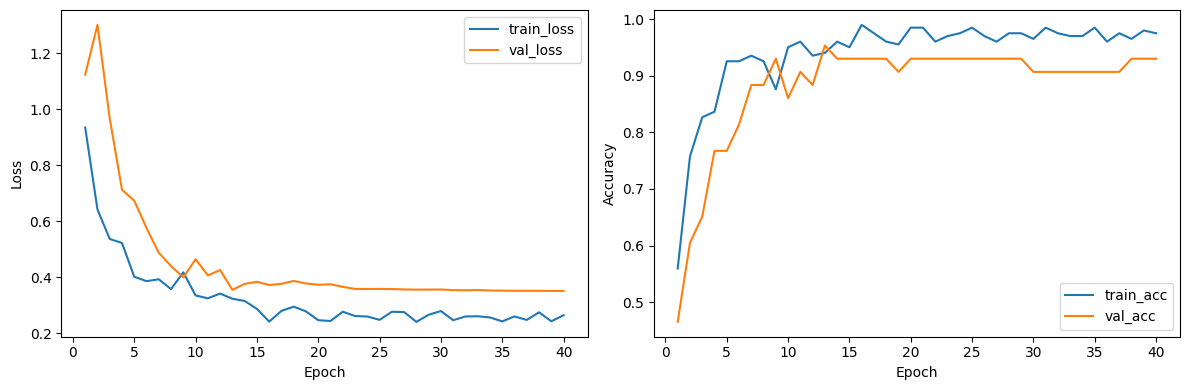

In [57]:
# 9) MobileNet 학습 노트북
epoch_axis = range(1, len(history['train_loss']) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epoch_axis, history['train_loss'], label='train_loss')
plt.plot(epoch_axis, history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epoch_axis, history['train_acc'], label='train_acc')
plt.plot(epoch_axis, history['val_acc'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


test_loss=0.3235, test_acc=0.9545
[[15  0  1]
 [ 1 14  0]
 [ 0  0 13]]
              precision    recall  f1-score   support

   Attentive       0.94      0.94      0.94        16
      Drowsy       1.00      0.93      0.97        15
 LookingAway       0.93      1.00      0.96        13

    accuracy                           0.95        44
   macro avg       0.96      0.96      0.96        44
weighted avg       0.96      0.95      0.95        44



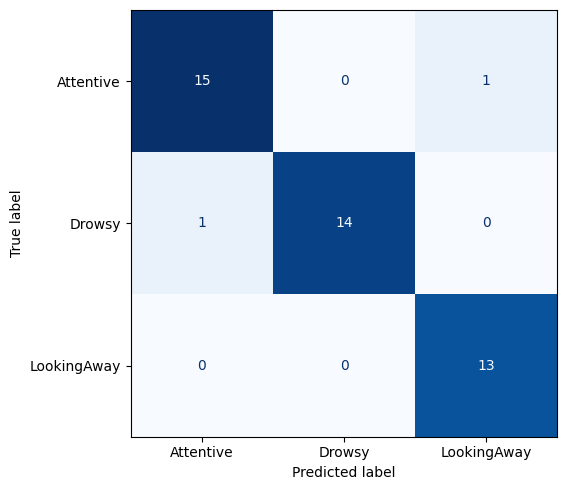

In [58]:
# 10) 학습된 최고 성능 모델은 `mobilenet/checkpoints` 아래에 저장됩니다.
best_ckpt = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE)
best_model = create_mobilenet(best_ckpt['model_name'], best_ckpt['num_classes'], pretrained=False, dropout=DROPOUT).to(DEVICE)
best_model.load_state_dict(best_ckpt['state_dict'])
best_model.eval()

test_loss, test_acc, y_true, y_pred = evaluate(best_model, test_loader, criterion, DEVICE)
print(f'test_loss={test_loss:.4f}, test_acc={test_acc:.4f}')
cm = confusion_matrix(y_true, y_pred)
print(cm)
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes).plot(ax=ax, cmap='Blues', colorbar=False)
plt.tight_layout()
plt.show()


In [59]:
# 11) 실행 방법
from PIL import Image

IMAGE_PATH = None  # PROJECT_ROOT / 'mobilenet_dataset' / 'test' / 'Attentive' / 'sample.jpg'


def predict_image(image_path, model, class_names, transform, device):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(image_tensor), dim=1).squeeze(0)
        pred_idx = int(probs.argmax().item())
    print('pred:', class_names[pred_idx], 'confidence:', f'{probs[pred_idx].item():.4f}')
    for class_name, prob in zip(class_names, probs.cpu().tolist()):
        print(f'- {class_name}: {prob:.4f}')


if IMAGE_PATH is not None:
    predict_image(IMAGE_PATH, best_model, best_ckpt['class_names'], eval_transform, DEVICE)


In [60]:
# 12) 웹캠 실시간 추론 화면 표시
# OpenCV 창을 종료하려면 q 키를 누르세요.
import cv2
from PIL import Image, ImageDraw, ImageFont

PREDICTION_WINDOW = 15
CONFIDENCE_THRESHOLD = 0.35

STATE_TEXT = {
    'Attentive': '집중',
    'Drowsy': '졸림',
    'LookingAway': '시선 이탈',
    'Collecting...': '판단 중',
    'Uncertain': '불확실',
    'No Face': '얼굴 없음',
}

# 클래스별로 화면 표시 색상을 다르게 지정합니다. BGR 순서입니다.
STATE_COLOR = {
    'Attentive': (40, 220, 40),
    'Drowsy': (40, 40, 235),
    'LookingAway': (0, 190, 255),
    'Collecting...': (255, 255, 255),
    'Uncertain': (180, 180, 180),
    'No Face': (120, 120, 120),
}


def get_korean_font(size):
    # Windows에서 한글 표시가 가능한 폰트를 우선 사용합니다.
    font_candidates = [
        r'C:\Windows\Fonts\malgun.ttf',
        r'C:\Windows\Fonts\malgunbd.ttf',
        r'C:\Windows\Fonts\gulim.ttc',
        r'C:\Windows\Fontsatang.ttc',
    ]
    for font_path in font_candidates:
        try:
            return ImageFont.truetype(font_path, size=size)
        except OSError:
            continue
    return ImageFont.load_default()


def draw_korean_text(frame, text, position, color, font):
    # cv2.putText는 한글이 깨질 수 있어 PIL로 텍스트를 그립니다.
    image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(image)
    draw.text(position, text, font=font, fill=color[::-1])
    return cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)


def crop_face_with_margin(frame, face_box, margin_ratio=0.25):
    # 얼굴 박스에 여유 영역을 더해 모델 입력으로 사용합니다.
    x, y, w, h = face_box
    height, width = frame.shape[:2]
    margin = int(max(w, h) * margin_ratio)
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(width, x + w + margin)
    y2 = min(height, y + h + margin)
    return frame[y1:y2, x1:x2], (x1, y1, x2, y2)


font_state = get_korean_font(30)
font_small = get_korean_font(18)
prediction_buffer = deque(maxlen=PREDICTION_WINDOW)
class_names = best_ckpt['class_names']

face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(face_cascade_path)
if face_cascade.empty():
    raise RuntimeError('얼굴 검출기를 불러오지 못했습니다.')

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError('웹캠을 열 수 없습니다.')

try:
    while True:
        ok, frame = cap.read()
        if not ok:
            break

        # 거울처럼 자연스럽게 보이도록 좌우반전합니다.
        frame = cv2.flip(frame, 1)

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80))

        if len(faces) == 0:
            stable_label = 'No Face'
            confidence = 0.0
            raw_label = 'No Face'
            color = STATE_COLOR[stable_label]
            frame = draw_korean_text(frame, STATE_TEXT[stable_label], (20, 30), color, font_state)
        else:
            # 여러 얼굴이 잡히면 가장 큰 얼굴을 대표로 사용합니다.
            face_box = max(faces, key=lambda box: box[2] * box[3])
            face_crop, draw_box = crop_face_with_margin(frame, face_box)
            x1, y1, x2, y2 = draw_box

            rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(rgb).convert('RGB')
            image_tensor = eval_transform(image).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                probs = torch.softmax(best_model(image_tensor), dim=1).squeeze(0)
                pred_idx = int(probs.argmax().item())
                confidence = float(probs[pred_idx].item())

            raw_label = class_names[pred_idx]
            pred_label = raw_label if confidence >= CONFIDENCE_THRESHOLD else 'Uncertain'
            prediction_buffer.append(pred_label)

            # 최근 예측을 모아 화면 표시를 안정화합니다.
            if len(prediction_buffer) < PREDICTION_WINDOW:
                stable_label = 'Collecting...'
            else:
                stable_label = Counter(prediction_buffer).most_common(1)[0][0]

            color = STATE_COLOR.get(stable_label, (255, 255, 255))
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
            cv2.rectangle(frame, (x1, max(0, y1 - 34)), (x2, y1), color, -1)
            frame = draw_korean_text(frame, STATE_TEXT.get(stable_label, stable_label), (x1 + 8, max(0, y1 - 32)), (255, 255, 255), font_small)

        state_text = STATE_TEXT.get(stable_label, stable_label)
        frame = draw_korean_text(frame, f'{state_text} ({confidence:.2f})', (20, 30), color, font_state)
        frame = draw_korean_text(frame, f'raw: {raw_label}', (20, 72), (255, 255, 255), font_small)
        frame = draw_korean_text(frame, 'q: quit', (20, 102), (255, 255, 255), font_small)

        cv2.imshow('MobileNet Focus Classifier', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
